# IS 4487 Lab 13

## Learning Objectives
1. Select appropriate variables for a cluster analysis
2. Learn to fit and adjust a cluster analysis model based on similar customer behavioural patterns.
3. Interpret the output of the model

## Lab Tasks
1. Import and prepare data using the *SuperStore Retail Orders* dataset
2. Convert categorical variables to numbers or boolean
3. Fit a K-means model with 5 clusters
4. Display and analyze the results

<a href="https://colab.research.google.com/github/Stan-Pugsley/is_4487_base/blob/main/Labs/Scripts/lab_13_retailer_cluster_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


## Superstore Data Dictionary

 ORDER VARIABLES:
 - Order ID
 - Order Date
 - Order Year Month - Year and month of the order
 - Order Type - Was the order completed at a store or online? (Retail, Online)
 - Quantity - Quantity ordered for the product

 CUSTOMER VARIABLES:
 - Customer Name
 - City
 - State Province
 - Email


PRODUCT VARIABLES:
 - Product Name
 - Product Line - Category of the product (i.e. Bikes Phones)
 - Product Price - Price in US Dollars
 - Product Status - Current status of the product (Active, Inactive)

## Load Libraries

➡️ Assignment Tasks
- Load any other necessary libraries, in addition to those below

In [1]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder
from sklearn.cluster import KMeans

## Import Data into Dataframe

➡️ Assignment Tasks
- Import data from the SuperStore retail dataset into a dataframe (in GitHub go to Labs > DataSets)
- Describe or profile the dataframe

In [7]:
#import data
df = pd.read_csv('https://raw.githubusercontent.com/Stan-Pugsley/is_4487_base/refs/heads/main/Labs/DataSets/superstore_retail_orders.csv')
print (df.head())

   order_id  order_date order_year_month  customer_name               city  \
0     51188  2023-07-01          2023-07  Audrey Blanco  North Cherylmouth   
1     51187  2023-07-01          2023-07    Isaac Allen         Traceyland   
2     51199  2023-07-02          2023-07     Ian Morgan          Dylanberg   
3     51241  2023-07-04          2023-07     Alexa Bell     Lake Tracytown   
4     51297  2023-07-08          2023-07     Casey Diaz        Byrdchester   

  state_province                    email order_type  quantity  \
0  New Hampshire  audrey_blanco@email.com     Retail       3.0   
1  West Virginia    isaac_allen@email.com     Online       4.0   
2   South Dakota     ian_morgan@email.com     Online       5.0   
3      Wisconsin     alexa_bell@email.com     Online       1.0   
4    Mississippi     casey_diaz@email.com     Online       1.0   

                                        product_name product_line  \
0  Apple iPhone XR (Yellow, 256 GB) (Includes Ear...       Mobile

## Prepare Data
Note that K-Means requires that all variables be numbers or boolean.  No categorical variables are allowed.

➡️ Assignment Tasks
- Copy your dataframe into a new version, so that the original data is still available
- Create any needed variables, such as month of year and total_amount.  
- Filter out any incomplete orders
- Convert the OrderType and Product Line variables to multiple one-hot variables using OneHotEncoder (one variable for each value)
- Remove any variables that will be not be included (hint: only numeric variables are allowed)
- Remove any outliers that will cause a cluster to be created for the few records with the outlier value (pay close attention to dates, quantities and prices)

*Notes:*
- There is no need to split the data for cluster analysis.  Why is that the case?
- You should think carefully about which variables to include.  They should be independent and numeric, and have some behavioural aspect for customers.  A date, for example, cannot be used unless it is somehow converted to a number.  

In [15]:
#create new dataframe and do any number conversion

# Create a copy of the dataframe
df_new = df.copy()

# Extract month from 'order_date' and create 'month_of_year' column
df_new['month_of_year'] = pd.to_datetime(df_new['order_date'], errors='coerce').dt.month

# Create a copy of the dataframe
df_new = df.copy()

# Extract month from 'order_date' and create 'month_of_year' column
df_new['month_of_year'] = pd.to_datetime(df_new['order_date'], errors='coerce').dt.month

# Calculate total amount and create 'total_amount' column
df_new['total_amount'] = df_new['quantity'] * df_new['product_price']
print(df_new.head())

   order_id  order_date order_year_month  customer_name               city  \
0     51188  2023-07-01          2023-07  Audrey Blanco  North Cherylmouth   
1     51187  2023-07-01          2023-07    Isaac Allen         Traceyland   
2     51199  2023-07-02          2023-07     Ian Morgan          Dylanberg   
3     51241  2023-07-04          2023-07     Alexa Bell     Lake Tracytown   
4     51297  2023-07-08          2023-07     Casey Diaz        Byrdchester   

  state_province                    email order_type  quantity  \
0  New Hampshire  audrey_blanco@email.com     Retail       3.0   
1  West Virginia    isaac_allen@email.com     Online       4.0   
2   South Dakota     ian_morgan@email.com     Online       5.0   
3      Wisconsin     alexa_bell@email.com     Online       1.0   
4    Mississippi     casey_diaz@email.com     Online       1.0   

                                        product_name product_line  \
0  Apple iPhone XR (Yellow, 256 GB) (Includes Ear...       Mobile

In [21]:
#filter records with incomplete or invalid data

# Filter out rows with invalid 'order_date' (NaN values after conversion)
df_new = df_new.dropna(subset=['month_of_year'])

# Filter out rows with negative quantities or prices
df_new = df_new[(df_new['quantity'] >= 0) & (df_new['product_price'] >= 0)]

#Further outlier removal (example, adjust thresholds as needed)
df_new = df_new[df_new['quantity'] < 100] # Example: Remove orders with quantity > 100
df_new = df_new[df_new['product_price'] < 500] # Example: Remove products with price > 500
df_new = df_new[df_new['total_amount'] < 10000] #Example: Remove total amount greater than 10000

print(df_new.head())

      order_id  order_date order_year_month       customer_name  \
7989     51187  2023-07-01          2023-07         Isaac Allen   
7990     51222  2023-07-03          2023-07        Dana Schmidt   
7991     51241  2023-07-04          2023-07          Alexa Bell   
7992     51243  2023-07-04          2023-07          Jaime Ruiz   
7993     51244  2023-07-04          2023-07  Virginia Fernandez   

                city state_province                         email order_type  \
7989      Traceyland  West Virginia         isaac_allen@email.com     Online   
7990  East Lorimouth      Minnesota        dana_schmidt@email.com     Retail   
7991  Lake Tracytown      Wisconsin          alexa_bell@email.com     Online   
7992      Mikaylaton      Tennessee          jaime_ruiz@email.com     Online   
7993        Alexfurt      Minnesota  virginia_fernandez@email.com     Retail   

      quantity  product_name product_line  product_price product_status  \
7989       2.0  LL Road Tire  Accessories

In [39]:
# Import necessary libraries
from sklearn.preprocessing import OneHotEncoder

# Assuming df is your original DataFrame

# Create a OneHotEncoder object
enc = OneHotEncoder(sparse_output=False, handle_unknown='ignore')  # sparse=False for dense output

# Fit the encoder on the 'order_type' and 'product_line' columns of the original dataframe (df)
enc.fit(df[['order_type', 'product_line']])

# Get feature names after one-hot encoding
feature_names = enc.get_feature_names_out(['order_type', 'product_line'])

# Transform the categorical features into one-hot encoded features
encoded_features = enc.transform(df[['order_type', 'product_line']])

# Create a new DataFrame from the one-hot encoded features
encoded_df = pd.DataFrame(encoded_features, columns=feature_names, index=df.index)

# Concatenate the one-hot encoded DataFrame with the original DataFrame
df = pd.concat([df, encoded_df], axis=1) # Changed df_new to df to use the original dataframe

# Remove the original 'order_type' and 'product_line' columns from the original dataframe
df = df.drop(['order_type', 'product_line'], axis=1) # Changed df_new to df to use the original dataframe

# Print the updated DataFrame
print(df.head())

   order_id  order_date order_year_month  customer_name               city  \
0     51188  2023-07-01          2023-07  Audrey Blanco  North Cherylmouth   
1     51187  2023-07-01          2023-07    Isaac Allen         Traceyland   
2     51199  2023-07-02          2023-07     Ian Morgan          Dylanberg   
3     51241  2023-07-04          2023-07     Alexa Bell     Lake Tracytown   
4     51297  2023-07-08          2023-07     Casey Diaz        Byrdchester   

  state_province                    email  quantity  \
0  New Hampshire  audrey_blanco@email.com       3.0   
1  West Virginia    isaac_allen@email.com       4.0   
2   South Dakota     ian_morgan@email.com       5.0   
3      Wisconsin     alexa_bell@email.com       1.0   
4    Mississippi     casey_diaz@email.com       1.0   

                                        product_name  product_price  ...  \
0  Apple iPhone XR (Yellow, 256 GB) (Includes Ear...         649.99  ...   
1  Apple iPhone XR (Yellow, 256 GB) (Includes Ea

In [40]:
#remove outliers
# Remove outliers based on IQR for numerical features
numerical_features = ['quantity', 'product_price', 'total_amount']
for feature in numerical_features:
    Q1 = df_new[feature].quantile(0.25)
    Q3 = df_new[feature].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df_new = df_new[(df_new[feature] >= lower_bound) & (df_new[feature] <= upper_bound)]

print(df_new.head())

       quantity  product_price  month_of_year  total_amount  \
12099       2.0           4.99            7.0          9.98   
12100       2.0           4.99            7.0          9.98   
12101       2.0           4.99            7.0          9.98   
12102       2.0           4.99            7.0          9.98   
12103       2.0           4.99            7.0          9.98   

       order_type_Online  order_type_Retail  product_line_Accessories  \
12099                0.0                1.0                       1.0   
12100                1.0                0.0                       1.0   
12101                1.0                0.0                       1.0   
12102                0.0                1.0                       1.0   
12103                1.0                0.0                       1.0   

       product_line_Clothing  product_line_Electronics  \
12099                    0.0                       0.0   
12100                    0.0                       0.0   
12101   

In [25]:
# prompt: eliminate order_ID, email, customer_name and keep all other variables

# Assuming df_new is the dataframe from the previous code
df_new = df_new.drop(columns=['order_id', 'email', 'customer_name'])
print(df_new.head())

      order_date order_year_month            city  state_province order_type  \
7989  2023-07-01          2023-07      Traceyland   West Virginia     Online   
7990  2023-07-03          2023-07  East Lorimouth       Minnesota     Retail   
7991  2023-07-04          2023-07  Lake Tracytown       Wisconsin     Online   
7992  2023-07-04          2023-07      Mikaylaton       Tennessee     Online   
7994  2023-07-07          2023-07       Apriltown  North Carolina     Online   

      quantity  product_name product_line  product_price product_status  ...  \
7989       2.0  LL Road Tire  Accessories          21.49         Active  ...   
7990       1.0  LL Road Tire  Accessories          21.49         Active  ...   
7991       1.0  LL Road Tire  Accessories          21.49         Active  ...   
7992       2.0  LL Road Tire  Accessories          21.49         Active  ...   
7994       2.0  LL Road Tire  Accessories          21.49         Active  ...   

      product_line_Electronics  produc

## Create Model

For more info on K-means in python, see: https://realpython.com/k-means-clustering-python/

➡️ Assignment Tasks
- Fit the K-means model using the Kmeans method
- Use 5 clusters

In [50]:
print(df_new.head())

# Impute missing values using the mean for numerical features
for feature in df_new.select_dtypes(include=['number']).columns:
    df_new[feature].fillna(df_new[feature].mean(), inplace=True)

# Impute missing values using the most frequent value for categorical features
for feature in df_new.select_dtypes(include=['object']).columns:
    df_new[feature].fillna(df_new[feature].mode()[0], inplace=True)

# Check if any columns still contain NaN values
print(df_new.isnull().sum())

# Drop rows with any remaining NaN values
df_new.dropna(inplace=True)  # Add this line to drop rows with NaNs

# Now, you can fit the KMeans model
kmeans = KMeans(n_clusters=5, random_state=0)
kmeans.fit(df_new)

       quantity  product_price  month_of_year  total_amount  \
12099       2.0           4.99            7.0          9.98   
12100       2.0           4.99            7.0          9.98   
12101       2.0           4.99            7.0          9.98   
12102       2.0           4.99            7.0          9.98   
12103       2.0           4.99            7.0          9.98   

       order_type_Online  order_type_Retail  product_line_Accessories  \
12099                0.0                1.0                       1.0   
12100                1.0                0.0                       1.0   
12101                1.0                0.0                       1.0   
12102                0.0                1.0                       1.0   
12103                1.0                0.0                       1.0   

       product_line_Clothing  product_line_Electronics  \
12099                    0.0                       0.0   
12100                    0.0                       0.0   
12101   

<ipython-input-50-9e40a21c90da>:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_new[feature].fillna(df_new[feature].mean(), inplace=True)
<ipython-input-50-9e40a21c90da>:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_new[feature].fillna(df_new[feature].mean(), inplace=True)


KMeans(n_clusters=5, random_state=0)

## Analyze the Clusters

➡️ Assignment Tasks
- create at least two visualizations to show the clusters (try a Bar Chart, Pair Plot or Scatter Plot)
- Display the cluster and mean values for each of the variables

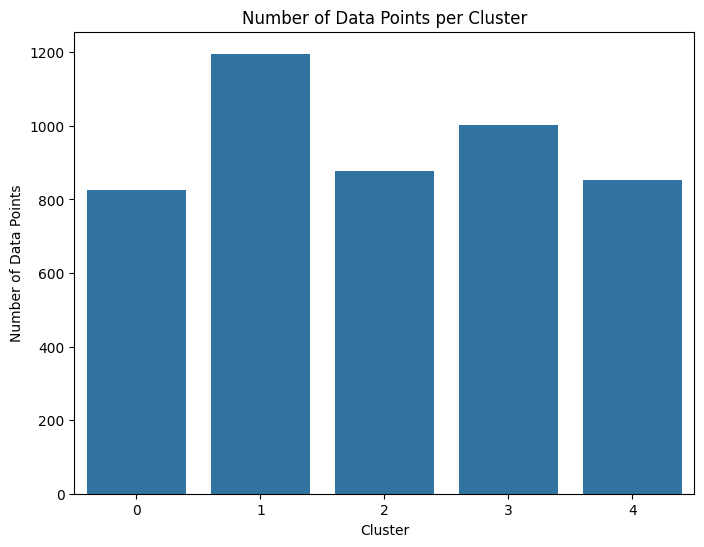

In [62]:
# prompt: create a bar chart to show the clusters

import matplotlib.pyplot as plt
import seaborn as sns

# Assuming 'kmeans' is your fitted KMeans model and 'df_new' is your DataFrame
# Get cluster labels for each data point
cluster_labels = kmeans.labels_

# Add cluster labels to the DataFrame
df_new['cluster'] = cluster_labels

# Create a bar chart to show the number of data points in each cluster
plt.figure(figsize=(8, 6))
sns.countplot(x='cluster', data=df_new)
plt.title('Number of Data Points per Cluster')
plt.xlabel('Cluster')
plt.ylabel('Number of Data Points')
plt.show()

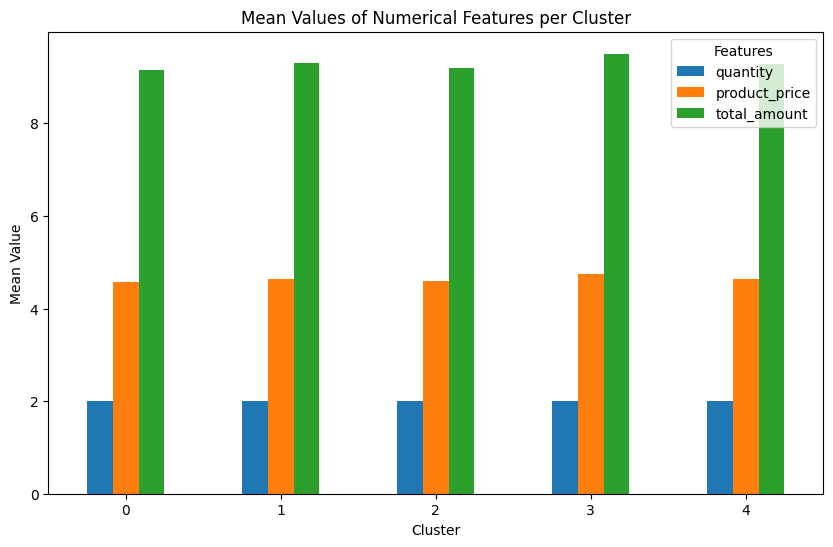

In [61]:
cluster_means = df_new.groupby('cluster').mean()

# Select numerical features for the bar chart
numerical_features_for_chart = ['quantity', 'product_price', 'total_amount'] # Example features

# Create the bar chart
cluster_means[numerical_features_for_chart].plot(kind='bar', figsize=(10, 6))
plt.title('Mean Values of Numerical Features per Cluster')
plt.xlabel('Cluster')
plt.ylabel('Mean Value')
plt.xticks(rotation=0)  # Rotate x-axis labels for better readability
plt.legend(title='Features')
plt.show()

In [58]:
# Assuming df_new is your DataFrame with the 'cluster' column
# Calculate summary statistics for each cluster
cluster_summary = df_new.groupby('cluster').describe()

# Display the summary statistics
cluster_summary

quantity                                    product_price            \
           count mean  std  min  25%  50%  75%  max         count      mean   
cluster                                                                       
0          825.0  2.0  0.0  2.0  2.0  2.0  2.0  2.0         825.0  4.576667   
1         1196.0  2.0  0.0  2.0  2.0  2.0  2.0  2.0        1196.0  4.647191   
2          877.0  2.0  0.0  2.0  2.0  2.0  2.0  2.0         877.0  4.602315   
3         1002.0  2.0  0.0  2.0  2.0  2.0  2.0  2.0        1002.0  4.752475   
4          852.0  2.0  0.0  2.0  2.0  2.0  2.0  2.0         852.0  4.644930   

         ... product_line_Clothing      product_line_OfficeProducts            \
         ...                   75%  max                       count mean  std   
cluster  ...                                                                    
0        ...                   0.0  0.0                       825.0  0.0  0.0   
1        ...                   0.0  0.0                      1196.0  0.0  0.0   
2        ...                   0.0  0.0                       877.0  0.0  0.0   
3        ...                   0.0  0.0                      1002.0  0.0  0.0   
4        ...                   0.0  0.0                       852.0  0.0  0.0   

                                  
         min  25%  50%  75%  max  
cluster                           
0        0.0  0.0  0.0  0.0  0.0  
1        0.0  0.0  0.0  0.0  0.0  
2        0.0  0.0  0.0  0.0  0.0  
3        0.0  0.0  0.0  0.0  0.0  
4        0.0  0.0  0.0  0.0  0.0  

[5 rows x 184 columns]